# DỰ ĐOÁN XU HƯỚNG ĐIỂM MUA VÀ BÁN
  . Mô tả bài toán

Trong thị trường chứng khoán, việc xác định thời điểm mua và bán cổ phiếu hợp lý đóng vai trò rất quan trọng để tối ưu lợi nhuận và giảm rủi ro. Tuy nhiên, việc xác định các điểm đảo chiều giá (Swing High / Swing Low) bằng phương pháp thủ công thường phụ thuộc nhiều vào kinh nghiệm của nhà đầu tư và dễ bị ảnh hưởng bởi nhiễu thị trường.

Bài toán đặt ra là xây dựng một mô hình Machine Learning có khả năng tự động dự đoán tín hiệu mua (BUY) và bán (SELL) dựa trên dữ liệu giá cổ phiếu lịch sử và các chỉ báo phân tích kỹ thuật.

## Mục tiêu của đề tài

Mục tiêu của đề tài là xây dựng một hệ thống dự đoán tín hiệu giao dịch cổ phiếu theo phương pháp Swing Trading bằng mô hình Logistic Regression kết hợp với các chỉ báo kỹ thuật như Supertrend, STC, Donchian Channel và ATR. Hệ thống nhằm xác định các điểm đảo chiều giá tiềm năng và lọc bỏ các tín hiệu nhiễu để nâng cao độ chính xác trong quá trình dự đoán tín hiệu mua và bán cổ phiếu trên thị trường chứng khoán Việt Nam.

## Load Data

In [1]:
!pip install git+https://github.com/rongardF/tvdatafeed.git

  Cloning https://github.com/rongardF/tvdatafeed.git to /tmp/pip-req-build-niwy2kp0
  Running command git clone --filter=blob:none --quiet https://github.com/rongardF/tvdatafeed.git /tmp/pip-req-build-niwy2kp0
  Resolved https://github.com/rongardF/tvdatafeed.git to commit e6f6aaa7de439ac6e454d9b26d2760ded8dc4923
  Preparing metadata (setup.py) ... done


## Load Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix
from tvDatafeed import TvDatafeed, Interval

In [3]:
tv = TvDatafeed()

ticker = "KBC"

df = tv.get_hist(
    symbol=ticker,
    exchange="HOSE",
    interval=Interval.in_daily,
    n_bars=5000
)

In [4]:
df.reset_index(inplace=True)

df.rename(columns={
    "datetime":"time"
}, inplace=True)

for col in ["open","high","low","close"]:
    df[col] = df[col] / 1000

## Indicator

In [5]:
# ================= SUPER TREND =================

def supertrend_kivanc(df, periods=10, multiplier=7.0):

    high = df["high"]
    low = df["low"]
    close = df["close"]

    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low - close.shift()).abs()
    ],axis=1).max(axis=1)

    atr = tr.ewm(alpha=1/periods,adjust=False).mean()

    src = (high + low)/2

    up = src - multiplier*atr
    dn = src + multiplier*atr

    final_up = up.copy()
    final_dn = dn.copy()

    trend = pd.Series(index=df.index,dtype=int)
    trend.iloc[0] = 1

    for i in range(1,len(df)):

        up1 = final_up.iloc[i-1]
        dn1 = final_dn.iloc[i-1]

        if close.iloc[i-1] > up1:
            final_up.iloc[i] = max(up.iloc[i],up1)
        else:
            final_up.iloc[i] = up.iloc[i]

        if close.iloc[i-1] < dn1:
            final_dn.iloc[i] = min(dn.iloc[i],dn1)
        else:
            final_dn.iloc[i] = dn.iloc[i]

        if trend.iloc[i-1] == -1 and close.iloc[i] > dn1:
            trend.iloc[i] = 1
        elif trend.iloc[i-1] == 1 and close.iloc[i] < up1:
            trend.iloc[i] = -1
        else:
            trend.iloc[i] = trend.iloc[i-1]

    df["supertrend_dir"] = trend
    df["supertrend"] = np.where(trend==1,final_up,final_dn)

    return df



In [6]:
# ================= STC =================

def stc_shayankm(close, fast=26, slow=50, cycle=12, alpha=0.5):

    macd = close.ewm(span=fast,adjust=False).mean() - \
           close.ewm(span=slow,adjust=False).mean()

    stoch1 = pd.Series(index=close.index,dtype=float)
    smooth1 = pd.Series(index=close.index,dtype=float)
    stoch2 = pd.Series(index=close.index,dtype=float)
    stc = pd.Series(index=close.index,dtype=float)

    for i in range(len(close)):

        if i < cycle:
            continue

        low1 = macd.iloc[i-cycle:i].min()
        high1 = macd.iloc[i-cycle:i].max()

        rng1 = high1 - low1

        if rng1 > 0:
            stoch1.iloc[i] = (macd.iloc[i]-low1)/rng1*100
        else:
            stoch1.iloc[i] = stoch1.iloc[i-1]

        if pd.isna(smooth1.iloc[i-1]):
            smooth1.iloc[i] = stoch1.iloc[i]
        else:
            smooth1.iloc[i] = smooth1.iloc[i-1] + alpha*(stoch1.iloc[i]-smooth1.iloc[i-1])

        low2 = smooth1.iloc[i-cycle:i].min()
        high2 = smooth1.iloc[i-cycle:i].max()

        rng2 = high2 - low2

        if rng2 > 0:
            stoch2.iloc[i] = (smooth1.iloc[i]-low2)/rng2*100
        else:
            stoch2.iloc[i] = stoch2.iloc[i-1]

        if pd.isna(stc.iloc[i-1]):
            stc.iloc[i] = stoch2.iloc[i]
        else:
            stc.iloc[i] = stc.iloc[i-1] + alpha*(stoch2.iloc[i]-stc.iloc[i-1])

    return stc.clip(0,100)

In [7]:
# ================= DONCHIAN =================

def donchian_trend_ribbon(df,lengths=(20,30,40,50)):

    score = pd.Series(0,index=df.index)

    for length in lengths:

        high = df["high"].rolling(length).max()
        low = df["low"].rolling(length).min()

        mid = (high+low)/2

        score += np.where(df["close"]>mid,1,-1)

    trend = score/len(lengths)

    df["donchian_trend"] = np.where(
        trend>0.5,1,
        np.where(trend<-0.5,-1,0)
    )

    return df


In [8]:
# ================= FEATURE ENGINEERING =================

df = supertrend_kivanc(df)

df["stc"] = stc_shayankm(df["close"])

df = donchian_trend_ribbon(df)

df["close_supertrend"] = df["close"] - df["supertrend"]


feature_cols = [
    "close",
    "supertrend_dir",
    "close_supertrend",
    "stc",
    "donchian_trend"
]


In [9]:
window = 5

df["label"] = np.nan

for i in range(window, len(df) - window):

    price = df["close"].iloc[i]

    past = df["close"].iloc[i-window:i]
    future = df["close"].iloc[i+1:i+window+1]

    # swing high → SELL
    if price >= past.max() and price >= future.max():
        df.iloc[i, df.columns.get_loc("label")] = -1

    # swing low → BUY
    elif price <= past.min() and price <= future.min():
        df.iloc[i, df.columns.get_loc("label")] = 1


# bỏ HOLD
df = df.dropna(subset=["label"])

df = df.dropna(subset=feature_cols)

## TRAIN

In [10]:
# ================= TRAIN TEST =================

split = int(len(df)*0.7)

X_train = df[feature_cols].iloc[:split]
X_test = df[feature_cols].iloc[split:]

y_train = df["label"].iloc[:split]
y_test = df["label"].iloc[split:]

In [11]:
# ================= SCALE =================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# ================= MODEL =================
param_grid = {
    "C": [0.01, 0.1, 0.5, 1, 5, 10],
    "penalty": ["l1", "l2", "elasticnet"],
    "solver": ["saga"],
    "l1_ratio": [0, 0.25, 0.5, 0.75, 1]
}

base_model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    class_weight="balanced",
    max_iter=5000
)

grid = GridSearchCV(
    base_model,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)


In [13]:
grid.fit(X_train_scaled,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=5000,
                                          multi_class='multinomial'),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 0.5, 1, 5, 10],
                         'l1_ratio': [0, 0.25, 0.5, 0.75, 1],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['saga']},
             scoring='f1_macro')

In [14]:
model = grid.best_estimator_

In [15]:
# ================= EVALUATE =================
y_pred = model.predict(X_test_scaled)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[77 10]
 [22 61]]
              precision    recall  f1-score   support

        -1.0       0.78      0.89      0.83        87
         1.0       0.86      0.73      0.79        83

    accuracy                           0.81       170
   macro avg       0.82      0.81      0.81       170
weighted avg       0.82      0.81      0.81       170



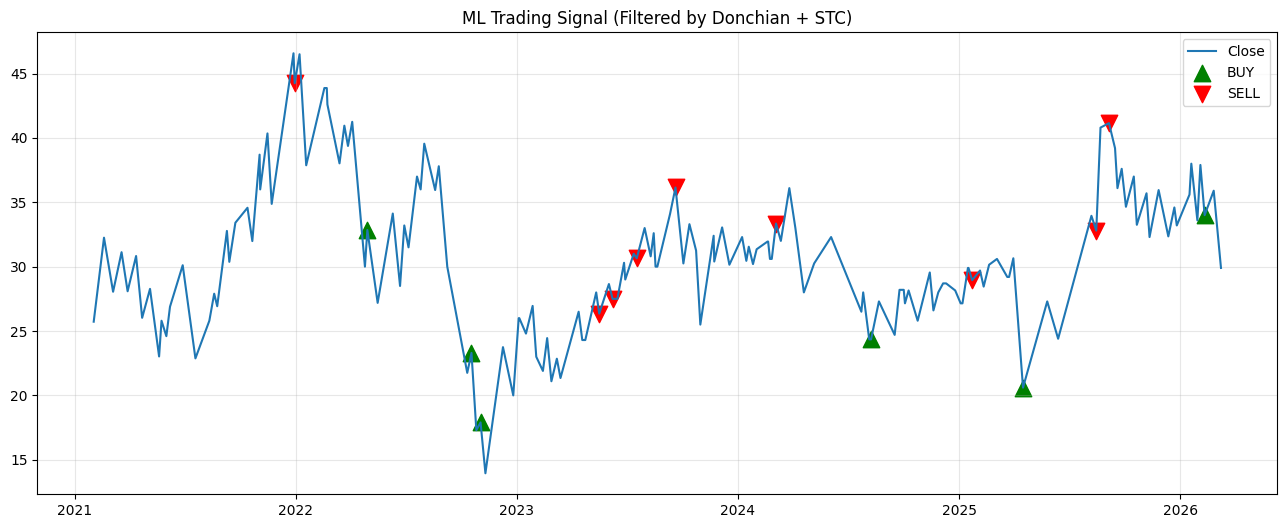

In [16]:
# ================= PREPARE TEST DATA =================

df_test = df.iloc[split:].copy()

df_test["ml_signal"] = y_pred


# ================= DONCHIAN CHANNEL =================

dc_len = 20

df_test["dc_high"] = df_test["high"].rolling(dc_len).max()
df_test["dc_low"] = df_test["low"].rolling(dc_len).min()


# ================= STC MOMENTUM =================

df_test["stc_diff"] = df_test["stc"].diff()


# ================= SIGNAL FILTER =================

buffer = 0.1

df_test["signal_plot"] = 0

for i in range(1, len(df_test)):

    ml = df_test["ml_signal"].iloc[i]

    close = df_test["close"].iloc[i]

    dc_high = df_test["dc_high"].iloc[i]
    dc_low = df_test["dc_low"].iloc[i]

    stc_diff = df_test["stc_diff"].iloc[i]

    prev = df_test["signal_plot"].iloc[i-1]

    # ===== BUY =====
    if (
        ml == 1
        and close <= dc_low * (1 + buffer)
        and stc_diff > 0
        and prev != 1
    ):
        df_test.iloc[i, df_test.columns.get_loc("signal_plot")] = 1

    # ===== SELL =====
    elif (
        ml == -1
        and close >= dc_high * (1 - buffer)
        and stc_diff < 0
        and prev != -1
    ):
        df_test.iloc[i, df_test.columns.get_loc("signal_plot")] = -1


# ================= PLOT =================

plot_data = df_test.tail(1200)

plt.figure(figsize=(16,6))

plt.plot(
    plot_data["time"],
    plot_data["close"],
    linewidth=1.5,
    label="Close"
)

# BUY SIGNAL
plt.scatter(
    plot_data.loc[plot_data["signal_plot"] == 1, "time"],
    plot_data.loc[plot_data["signal_plot"] == 1, "close"],
    marker="^",
    color="green",
    s=140,
    label="BUY"
)

# SELL SIGNAL
plt.scatter(
    plot_data.loc[plot_data["signal_plot"] == -1, "time"],
    plot_data.loc[plot_data["signal_plot"] == -1, "close"],
    marker="v",
    color="red",
    s=140,
    label="SELL"
)

plt.legend()

plt.grid(alpha=0.3)

plt.title("ML Trading Signal (Filtered by Donchian + STC)")

plt.show()

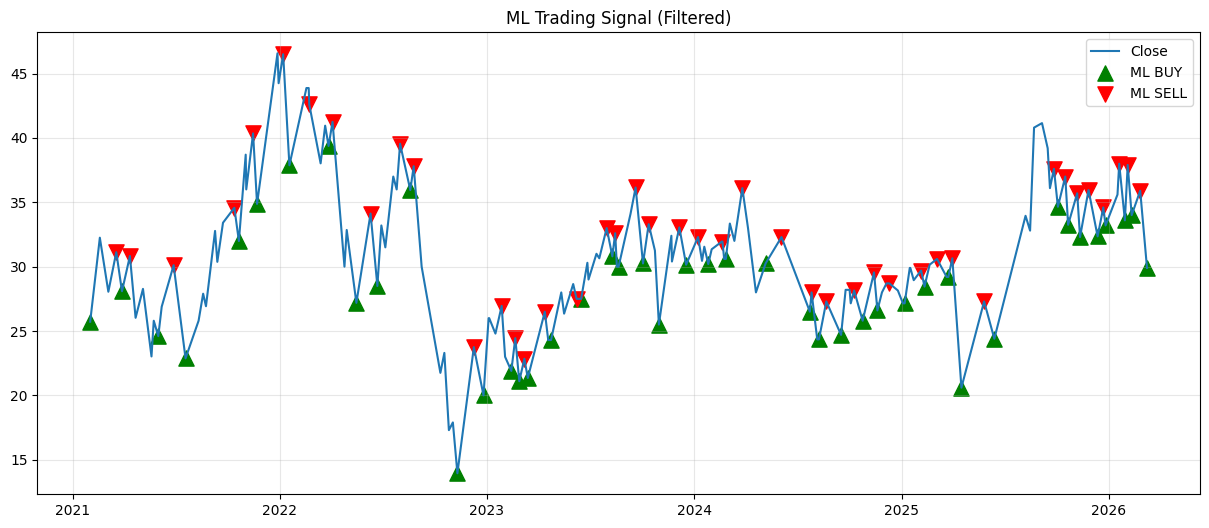

In [19]:
# ================= PLOT SIGNAL =================

df_test = df.iloc[split:].copy()

df_test["ml_signal"] = y_pred

# chỉ giữ điểm cuối của chuỗi BUY/SELL
df_test["plot_signal"] = df_test["ml_signal"]

df_test["plot_signal"] = df_test["plot_signal"].where(
    df_test["plot_signal"] != df_test["plot_signal"].shift(-1)
)

plot_data = df_test.tail(500)

plt.figure(figsize=(15,6))

plt.plot(
    plot_data["time"],
    plot_data["close"],
    label="Close"
)

# BUY
plt.scatter(
    plot_data.loc[plot_data["plot_signal"]==1,"time"],
    plot_data.loc[plot_data["plot_signal"]==1,"close"],
    marker="^",
    color="green",
    s=120,
    label="ML BUY"
)

# SELL
plt.scatter(
    plot_data.loc[plot_data["plot_signal"]==-1,"time"],
    plot_data.loc[plot_data["plot_signal"]==-1,"close"],
    marker="v",
    color="red",
    s=120,
    label="ML SELL"
)

plt.legend()
plt.grid(alpha=0.3)

plt.title("ML Trading Signal (Filtered)")

plt.show()

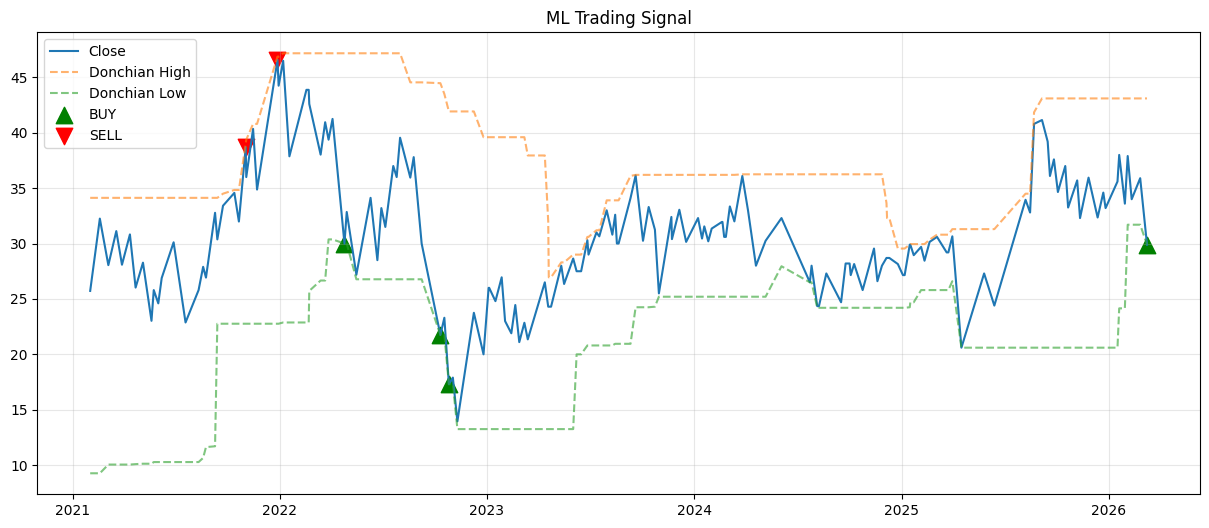

In [20]:
# ================= INDICATORS =================

# Donchian Channel
donchian_period = 20

df["donchian_high"] = df["high"].rolling(donchian_period).max()
df["donchian_low"] = df["low"].rolling(donchian_period).min()

# ATR
atr_period = 14

df["H-L"] = df["high"] - df["low"]
df["H-C"] = abs(df["high"] - df["close"].shift())
df["L-C"] = abs(df["low"] - df["close"].shift())

df["TR"] = df[["H-L","H-C","L-C"]].max(axis=1)
df["ATR"] = df["TR"].rolling(atr_period).mean()

# ================= ML PREDICTION =================

df_test = df.iloc[split:].copy()

df_test["ml_signal"] = y_pred


# ================= FILTER 1 (DONCHIAN) =================

df_test["signal"] = 0

# BUY gần đáy
df_test.loc[
    (df_test["ml_signal"] == 1) &
    (df_test["close"] <= df_test["donchian_low"] * 1.01),
    "signal"
] = 1

# SELL gần đỉnh
df_test.loc[
    (df_test["ml_signal"] == -1) &
    (df_test["close"] >= df_test["donchian_high"] * 0.99),
    "signal"
] = -1


# ================= FILTER 2 (ATR VOLATILITY) =================

atr_threshold = df_test["ATR"].median()

df_test.loc[df_test["ATR"] < atr_threshold, "signal"] = 0


# ================= FILTER 3 (ONLY LAST SIGNAL) =================

df_test["plot_signal"] = df_test["signal"]

df_test["plot_signal"] = df_test["plot_signal"].where(
    df_test["plot_signal"] != df_test["plot_signal"].shift(-1)
)

# ================= PLOT =================

plot_data = df_test.tail(1500)

plt.figure(figsize=(15,6))

plt.plot(
    plot_data["time"],
    plot_data["close"],
    label="Close"
)

# Donchian
plt.plot(
    plot_data["time"],
    plot_data["donchian_high"],
    linestyle="dashed",
    alpha=0.6,
    label="Donchian High"
)

plt.plot(
    plot_data["time"],
    plot_data["donchian_low"],
    linestyle="dashed",
    alpha=0.6,
    label="Donchian Low"
)

# BUY
plt.scatter(
    plot_data.loc[plot_data["plot_signal"]==1,"time"],
    plot_data.loc[plot_data["plot_signal"]==1,"close"],
    marker="^",
    color="green",
    s=140,
    label="BUY"
)

# SELL
plt.scatter(
    plot_data.loc[plot_data["plot_signal"]==-1,"time"],
    plot_data.loc[plot_data["plot_signal"]==-1,"close"],
    marker="v",
    color="red",
    s=140,
    label="SELL"
)

plt.legend()

plt.grid(alpha=0.3)

plt.title("ML Trading Signal")

plt.show()

## Lưu Model

In [21]:
import joblib
joblib.dump(model, "/content/drive/MyDrive/BuyOrSell/model/model.pkl")

['/content/drive/MyDrive/BuyOrSell/model/model.pkl']

In [22]:
joblib.dump(scaler, "/content/drive/MyDrive/BuyOrSell/model/scaler.pkl")

['/content/drive/MyDrive/BuyOrSell/model/scaler.pkl']